In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import urllib.request
import tqdm
import matplotlib.pyplot as plt

In [7]:
# 1. Setup Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 2. Load Evaluation Dataset (WikiText-2)
print("Loading WikiText-2 evaluation dataset...")
# Replace the old load_dataset line with this:
url = "https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/test.txt"

with urllib.request.urlopen(url) as response:
    raw_text = response.read().decode('utf-8')

# 3. Target GPT-2 Variants and their approximate parameter counts
gpt2_variants = {
    "gpt2": 124e6,
    "gpt2-medium": 355e6,
    "gpt2-large": 774e6,
    "gpt2-xl": 1.5e9
}

results = {}

Using device: cuda
Loading WikiText-2 evaluation dataset...


In [ ]:
# 4. Evaluation Loop across variants
for model_name in gpt2_variants.keys():
    print(f"\n--- Evaluating {model_name} ---")
    
    # Load specific model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()
    
    # Tokenize the raw string
    encodings = tokenizer(raw_text, return_tensors="pt")
    
    max_length = model.config.n_positions  # 1024 for GPT-2
    stride = 512
    seq_len = encodings.input_ids.size(1)
    
    nlls = []
    prev_end_loc = 0
    # Sliding window evaluation loop
    for begin_loc in tqdm.tqdm(range(0, seq_len, stride)):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc  # tokens evaluated in this step
        
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        
        # Mask out labels belonging to the overlap context window history
        target_ids[:, :-trg_len] = -100
        
        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            # loss is calculated automatically via cross-entropy over non-masked targets
            neg_log_likelihood = outputs.loss
            
        nlls.append(neg_log_likelihood * trg_len)
        prev_end_loc = end_loc
        if end_loc == seq_len:
            break
    # Compute baseline perplexity
    ppl = torch.exp(torch.stack(nlls).sum() / end_loc).item()
    print(f"Final Perplexity for {model_name}: {ppl:.4f}")
    results[model_name] = ppl
    
    # Clean up GPU memory allocations immediately
    del model
    torch.cuda.empty_cache()

In [9]:
# 5. Compile and Plot the Scaling Metrics
print("\n--- Final Summary Results ---")
for k, v in results.items():
    print(f"Model: {k} | Parameters: {gpt2_variants[k]:,.0f} | Perplexity: {v:.4f}")

# Generate Scaling Curve Visual Output
param_sizes = [gpt2_variants[m]/1e6 for m in gpt2_variants.keys()] # Convert to Millions
perplexity_values = [results[m] for m in gpt2_variants.keys()]


--- Final Summary Results ---
Model: gpt2 | Parameters: 124,000,000 | Perplexity: 19.6220
Model: gpt2-medium | Parameters: 355,000,000 | Perplexity: 15.2567
Model: gpt2-large | Parameters: 774,000,000 | Perplexity: 13.3782
Model: gpt2-xl | Parameters: 1,500,000,000 | Perplexity: 12.5566


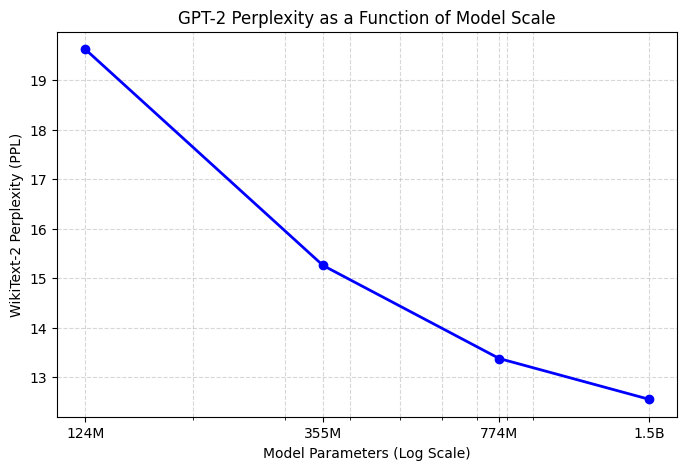

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(param_sizes, perplexity_values, marker='o', linestyle='-', color='b', linewidth=2)
plt.xscale('log') # Scaling laws show linear trends clearly on logarithmic scales
plt.xticks(param_sizes, labels=[f"{int(x)}M" if x < 1000 else f"{x/1000:.1f}B" for x in param_sizes])
plt.xlabel("Model Parameters (Log Scale)")
plt.ylabel("WikiText-2 Perplexity (PPL)")
plt.title("GPT-2 Perplexity as a Function of Model Scale")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.savefig("gpt2_perplexity_scaling.png", dpi=300)
plt.show()